# Skateboard problem: nonlinear motion vs. small-angle approximation

This notebook studies the motion of a skateboard on a circular ramp. We solve the exact nonlinear equation numerically and compare it with the closed-form solution of the small-angle approximation.

The exact equation is

$$
\ddot{\theta} = -\frac{g}{R}\sin\theta,
$$

and for small angles we use

$$
\sin\theta \approx \theta,
$$

so that

$$
\ddot{\theta} + \frac{g}{R}\theta = 0.
$$


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.style.use("seaborn-v0_8")
%matplotlib inline


## Define physical parameters and initial conditions

Set the gravitational acceleration, radius of curvature, initial angle, and time interval for the numerical integration.

In [47]:
g = 9.81
R = 5.0
theta0 = 0.2  # radians
omega0_init = 0.0
t_span = (0.0, 8.0)
t_eval = np.linspace(*t_span, 400)


## Implement the ODE as a first-order system

We write the second-order equation as a system for y = [theta, omega].

In [48]:
def rhs(t, y):
    theta, omega = y
    return [omega, -(g / R) * np.sin(theta)]


## Numerical solve with solve_ivp

Use a high-accuracy solver to integrate the system numerically.

In [49]:
sol = solve_ivp(
    rhs,
    t_span,
    [theta0, omega0_init],
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12,
    dense_output=True,
)

t = sol.t
theta_num = sol.y[0]


## Closed-form small-angle solution

For small angles, the equation reduces to simple harmonic motion with angular frequency omega0 = sqrt(g/R).

In [50]:
omega0 = np.sqrt(g / R)
theta_small = theta0 * np.cos(omega0 * t) + (omega0_init / omega0) * np.sin(omega0 * t)
error = theta_num - theta_small


## Compare numerical and analytic trajectories

Plot the two solutions and their pointwise difference.

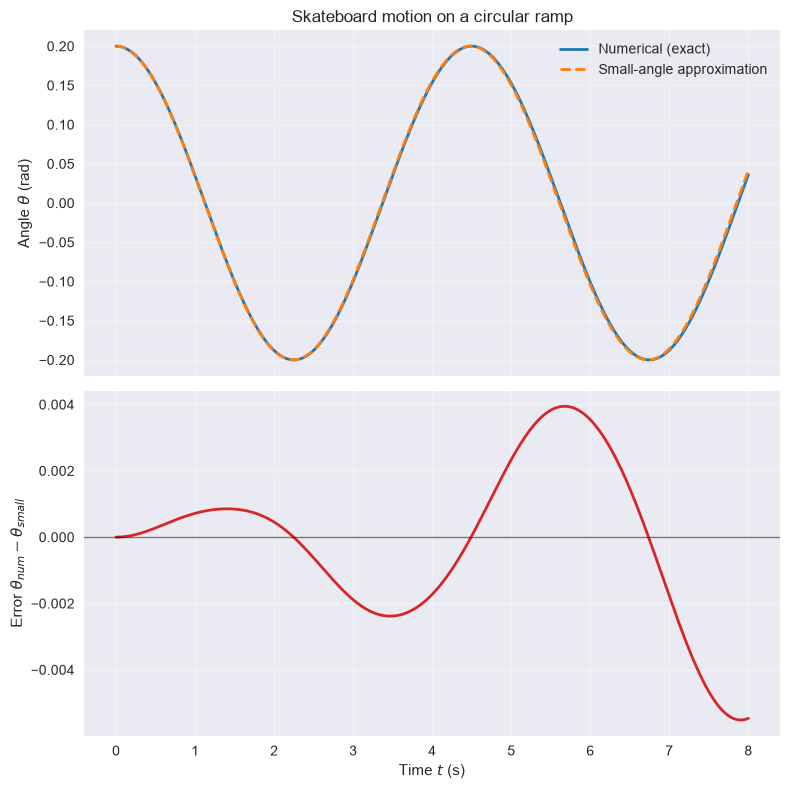

In [51]:
fig_comparison, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t, theta_num, label='Numerical (exact)', color='tab:blue', lw=2)
axes[0].plot(t, theta_small, label='Small-angle approximation', color='tab:orange', ls='--', lw=2)
axes[0].set_ylabel('Angle $\\theta$ (rad)')
axes[0].set_title('Skateboard motion on a circular ramp')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(t, error, color='tab:red', lw=2)
axes[1].axhline(0, color='black', lw=1, alpha=0.5)
axes[1].set_xlabel('Time $t$ (s)')
axes[1].set_ylabel('Error $\\theta_{num} - \\theta_{small}$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Position comparison in the ramp plane

Plot the two trajectories in physical space using the circular ramp coordinates $x = R \sin\theta$ and $y = -R \cos\theta$.

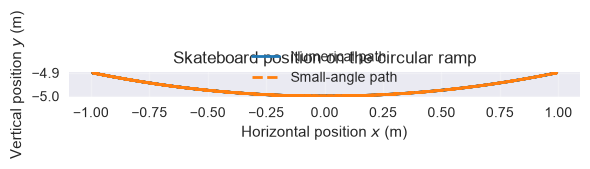

In [52]:
x_num = R * np.sin(theta_num)
y_num = -R * np.cos(theta_num)
x_small = R * np.sin(theta_small)
y_small = -R * np.cos(theta_small)

fig_position, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_num, y_num, label='Numerical path', color='tab:blue', lw=2)
ax.plot(x_small, y_small, label='Small-angle path', color='tab:orange', ls='--', lw=2)
ax.set_aspect('equal', 'box')
ax.set_xlabel('Horizontal position $x$ (m)')
ax.set_ylabel('Vertical position $y$ (m)')
ax.set_title('Skateboard position on the circular ramp')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


## Angle vs time for different initial angles

Show only the angle $\theta(t)$ curves for eight initial angles from very small to large, so the breakdown of the small-angle approximation is visible in time.

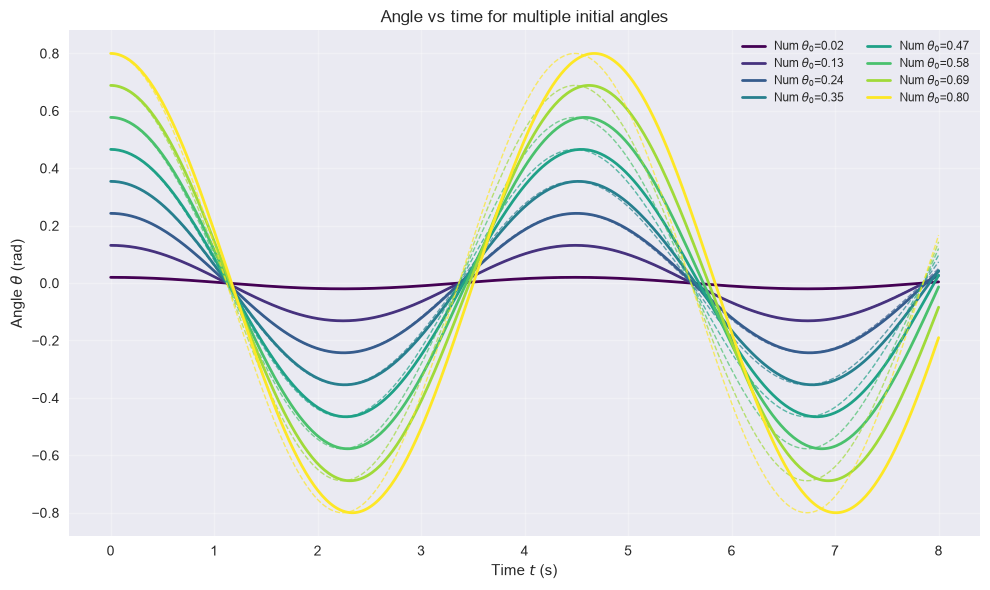

In [53]:
angle_values = np.linspace(0.02, 0.8, 8)
colors = plt.cm.viridis(np.linspace(0, 1, len(angle_values)))

fig_multi, ax = plt.subplots(figsize=(10, 6))
for theta0_plot, color in zip(angle_values, colors):
    sol = solve_ivp(
        rhs,
        t_span,
        [theta0_plot, omega0_init],
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12,
    )
    theta_num_plot = sol.y[0]
    theta_small_plot = theta0_plot * np.cos(omega0 * t_eval) + (omega0_init / omega0) * np.sin(omega0 * t_eval)

    ax.plot(t_eval, theta_num_plot, label=f'Num $\\theta_0$={theta0_plot:.2f}', color=color, lw=2)
    ax.plot(t_eval, theta_small_plot, ls='--', color=color, lw=1, alpha=0.7)

ax.set_xlabel('Time $t$ (s)')
ax.set_ylabel('Angle $\\theta$ (rad)')
ax.set_title('Angle vs time for multiple initial angles')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()


## Error metrics and parameter sweep over initial angle

We now compare the two models over a range of initial angles to see when the small-angle approximation breaks down.

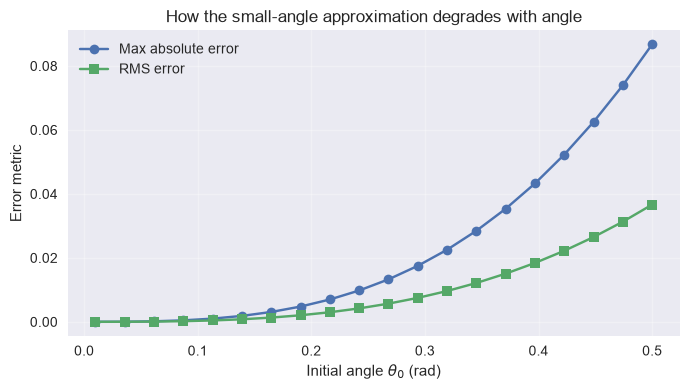

In [54]:
angles = np.linspace(0.01, 0.5, 20)
max_errors = []
rms_errors = []

for theta0 in angles:
    sol = solve_ivp(
        rhs,
        t_span,
        [theta0, omega0_init],
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12,
    )
    theta_num = sol.y[0]
    theta_small = theta0 * np.cos(omega0 * t_eval) + (omega0_init / omega0) * np.sin(omega0 * t_eval)
    error = theta_num - theta_small
    max_errors.append(np.max(np.abs(error)))
    rms_errors.append(np.sqrt(np.mean(error**2)))

fig_error, ax = plt.subplots(figsize=(7, 4))
ax.plot(angles, max_errors, marker='o', label='Max absolute error')
ax.plot(angles, rms_errors, marker='s', label='RMS error')
ax.set_xlabel('Initial angle $\\theta_0$ (rad)')
ax.set_ylabel('Error metric')
ax.set_title('How the small-angle approximation degrades with angle')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Unit tests for small-angle agreement

The following tests check that the numerical solution and the small-angle solution agree closely for a very small initial angle.

In [55]:
def test_small_angle_agreement():
    theta0_test = 1e-3
    t_test = np.linspace(0, 4 * 2 * np.pi * np.sqrt(R / g), 400)
    sol = solve_ivp(
        rhs,
        (0.0, t_test[-1]),
        [theta0_test, 0.0],
        t_eval=t_test,
        rtol=1e-10,
        atol=1e-12,
    )
    theta_num = sol.y[0]
    theta_small = theta0_test * np.cos(np.sqrt(g / R) * t_test)
    assert np.max(np.abs(theta_num - theta_small)) < 1e-5


test_small_angle_agreement()


## Save/export results and figures

Save the comparison plot and numeric results for later inspection.

In [ ]:
import os

output_dir = os.path.join(os.getcwd(), '..', 'figures')
os.makedirs(output_dir, exist_ok=True)

fig_comparison.savefig(os.path.join(output_dir, 'skateboard_time_compare.png'), dpi=200)
fig_comparison.savefig(os.path.join(output_dir, 'skateboard_time_compare.pdf'))
fig_position.savefig(os.path.join(output_dir, 'skateboard_position.png'), dpi=200)
fig_position.savefig(os.path.join(output_dir, 'skateboard_position.pdf'))
fig_multi.savefig(os.path.join(output_dir, 'skateboard_multi_angle.png'), dpi=200)
fig_multi.savefig(os.path.join(output_dir, 'skateboard_multi_angle.pdf'))
fig_error.savefig(os.path.join(output_dir, 'skateboard_error_metrics.png'), dpi=200)
fig_error.savefig(os.path.join(output_dir, 'skateboard_error_metrics.pdf'))

np.savetxt(
    os.path.join(output_dir, 'skateboard_results.csv'),
    np.column_stack([t, theta_num, theta_small, error]),
    delimiter=',',
    header='t,theta_num,theta_small,error',
    comments='',
)

: 